# Matplotlib and seaborn library

In [2]:
import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use("Agg")            # headless backend -> save to file, no display needed
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")   # nicer default look; optional
np.random.seed(42)                 # reproducible fake data

# 0. Build a realistic dataset: restaurant tips

In [3]:
n = 200
days = np.random.choice(["Thur", "Fri", "Sat", "Sun"], size=n, p=[0.2, 0.2, 0.35, 0.25])
time = np.where(np.isin(days, ["Sat", "Sun"]),
                np.random.choice(["Lunch", "Dinner"], n, p=[0.4, 0.6]),
                np.random.choice(["Lunch", "Dinner"], n, p=[0.3, 0.7]))
sex = np.random.choice(["Male", "Female"], size=n)
smoker = np.random.choice(["Yes", "No"], size=n, p=[0.35, 0.65])
party_size = np.random.choice([1, 2, 3, 4, 5, 6], size=n, p=[.05, .45, .2, .18, .07, .05])
 
# total_bill scales with party size + noise; tip is ~15-20% of bill + noise
total_bill = np.round(party_size * np.random.normal(9, 2, n) + np.random.normal(5, 3, n), 2)
total_bill = np.clip(total_bill, 3, None)
tip = np.round(total_bill * np.random.normal(0.17, 0.04, n) + np.random.normal(0, 0.4, n), 2)
tip = np.clip(tip, 0.5, None)
 
df = pd.DataFrame({
    "total_bill": total_bill, "tip": tip, "party_size": party_size,
    "day": days, "time": time, "sex": sex, "smoker": smoker,
})
df["tip_pct"] = (df["tip"] / df["total_bill"] * 100).round(1)
print("Dataset head:\n", df.head(), "\n\nshape ->", df.shape)

Dataset head:
    total_bill   tip  party_size   day    time     sex smoker  tip_pct
0       27.03  6.15           2   Fri   Lunch    Male     No     22.8
1       10.84  0.61           1   Sun   Lunch  Female    Yes      5.6
2       19.59  4.94           2   Sat   Lunch  Female    Yes     25.2
3       38.35  7.31           3   Sat  Dinner  Female    Yes     19.1
4       22.42  3.70           2  Thur  Dinner    Male    Yes     16.5 

shape -> (200, 8)


# 1. HISTOGRAM — distribution of one numeric variable

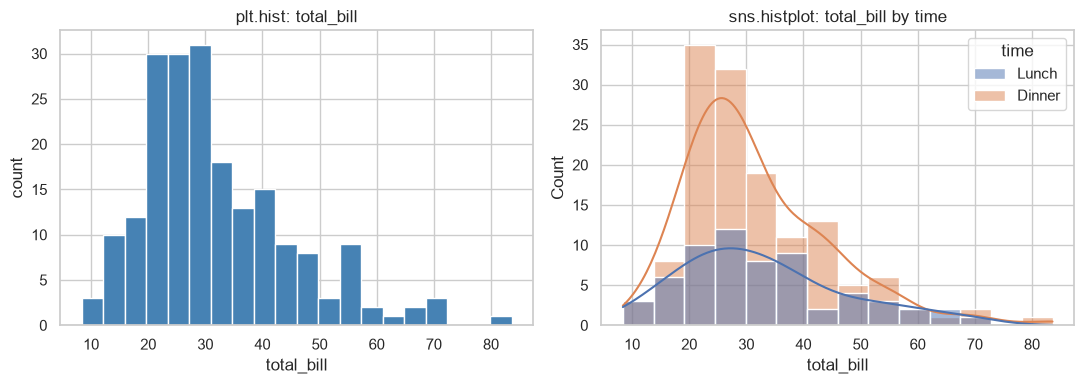

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
 
# matplotlib: plt.hist on an Axes
axes[0].hist(df["total_bill"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("plt.hist: total_bill")
axes[0].set_xlabel("total_bill")
axes[0].set_ylabel("count")
 
# seaborn: histplot with a density curve, split by a category via hue
sns.histplot(data=df, x="total_bill", hue="time", kde=True, ax=axes[1])
axes[1].set_title("sns.histplot: total_bill by time")
 
fig.tight_layout()
plt.show()

# 2. SCATTER — relationship between two numeric variables

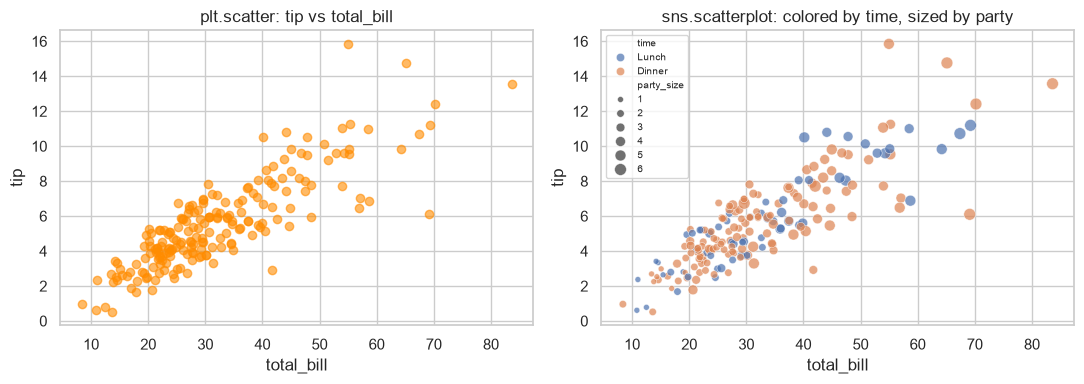

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
 
# matplotlib scatter
axes[0].scatter(df["total_bill"], df["tip"], alpha=0.6, color="darkorange")
axes[0].set_title("plt.scatter: tip vs total_bill")
axes[0].set_xlabel("total_bill")
axes[0].set_ylabel("tip")
 
# seaborn scatter with hue (color) AND size encoding a third/fourth variable
sns.scatterplot(data=df, x="total_bill", y="tip",
                hue="time", size="party_size", alpha=0.7, ax=axes[1])
axes[1].set_title("sns.scatterplot: colored by time, sized by party")
axes[1].legend(fontsize=7, loc="upper left")
 
fig.tight_layout()
plt.show()

# 3. BOXPLOT — distribution across categories + outliers

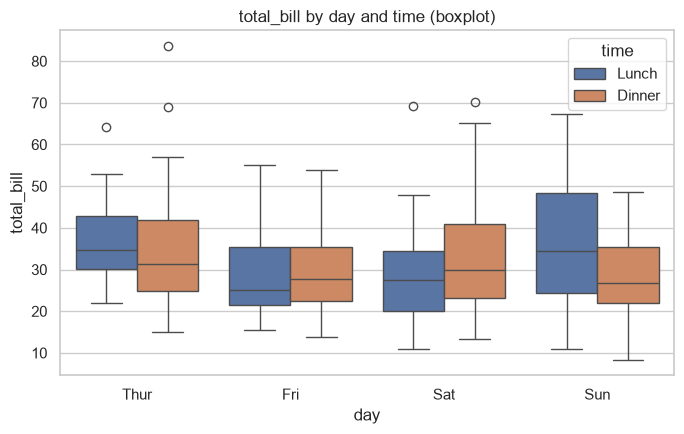

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
# A box per day, split by time — great for spotting spread and outliers.
sns.boxplot(data=df, x="day", y="total_bill", hue="time",
            order=["Thur", "Fri", "Sat", "Sun"], ax=ax)
ax.set_title("total_bill by day and time (boxplot)")
fig.tight_layout()
plt.show()

# 4 . BAR CHART — an aggregate per category

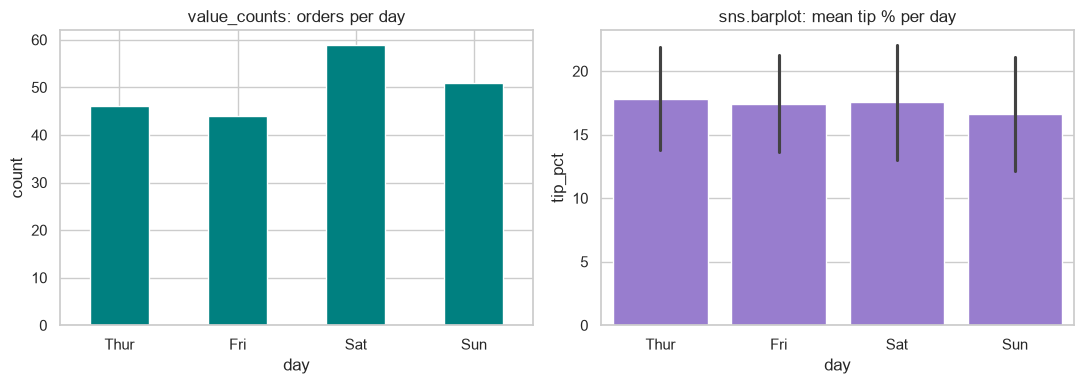

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
 
# (a) value_counts().plot(kind='bar') — quick frequency of a category
df["day"].value_counts().reindex(["Thur", "Fri", "Sat", "Sun"]).plot(
    kind="bar", ax=axes[0], color="teal")
axes[0].set_title("value_counts: orders per day")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)
 
# (b) sns.barplot — shows the MEAN of y per category (with error bars)
sns.barplot(data=df, x="day", y="tip_pct",
            order=["Thur", "Fri", "Sat", "Sun"], ax=axes[1],
            errorbar="sd", color="mediumpurple")
axes[1].set_title("sns.barplot: mean tip % per day")
 
fig.tight_layout()
plt.show()


# 5. LINE CHART — a trend (here: mean tip % by party size)

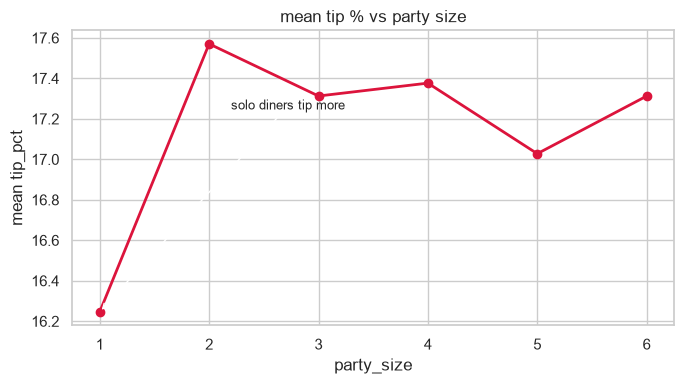

In [8]:
trend = df.groupby("party_size")["tip_pct"].mean()
fig, ax = plt.subplots(figsize=(7, 4))
# matplotlib line
ax.plot(trend.index, trend.values, marker="o", linewidth=2, color="crimson")
ax.set_title("mean tip % vs party size")
ax.set_xlabel("party_size")
ax.set_ylabel("mean tip_pct")
# annotate a point to show text placement
ax.annotate("solo diners tip more",
            xy=(1, trend.loc[1]), xytext=(2.2, trend.loc[1] + 1),
            arrowprops=dict(arrowstyle="->"), fontsize=9)
fig.tight_layout()

# 6. CORRELATION HEATMAP — numeric relationships at a glance

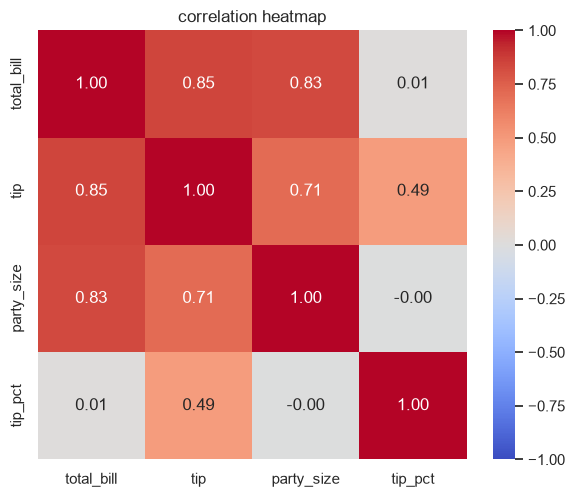

In [9]:
num = df[["total_bill", "tip", "party_size", "tip_pct"]]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("correlation heatmap")
fig.tight_layout()
plt.show()

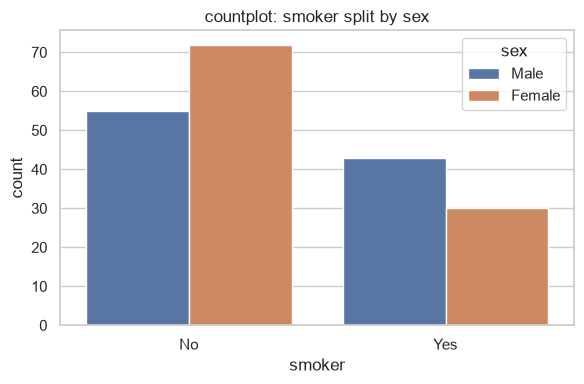

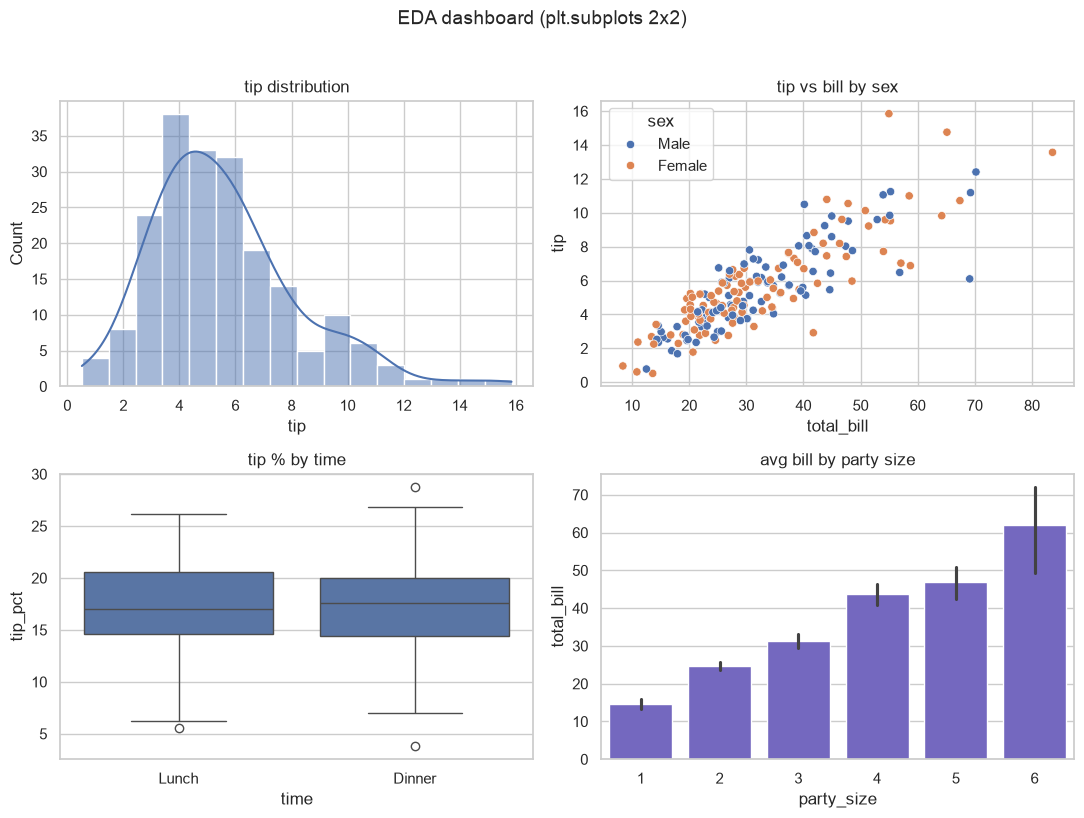

In [11]:
# 7. EXTRAS — countplot, and a 2x2 subplots dashboard

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="smoker", hue="sex", ax=ax)
ax.set_title("countplot: smoker split by sex")
fig.tight_layout()
plt.show()
# A 2x2 dashboard showing plt.subplots layout control + styling calls
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
sns.histplot(data=df, x="tip", kde=True, ax=axes[0, 0])
axes[0, 0].set_title("tip distribution")
 
sns.scatterplot(data=df, x="total_bill", y="tip", hue="sex", ax=axes[0, 1])
axes[0, 1].set_title("tip vs bill by sex")
 
sns.boxplot(data=df, x="time", y="tip_pct", ax=axes[1, 0])
axes[1, 0].set_title("tip % by time")
 
sns.barplot(data=df, x="party_size", y="total_bill", ax=axes[1, 1], color="slateblue")
axes[1, 1].set_title("avg bill by party size")
 
fig.suptitle("EDA dashboard (plt.subplots 2x2)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

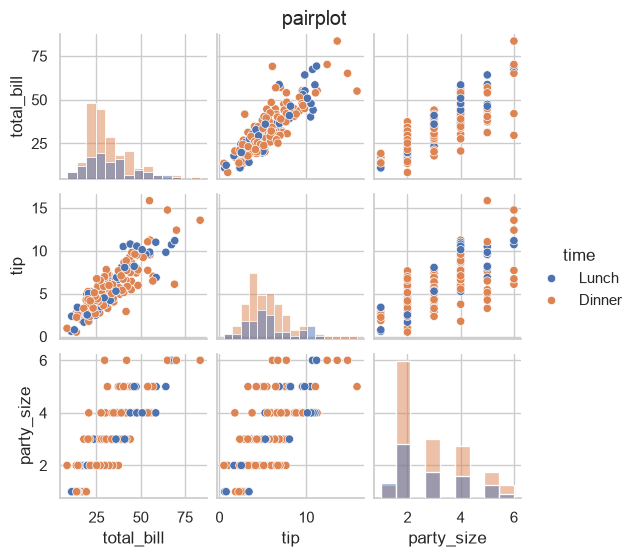

In [15]:
# 8. PAIRPLOT — all pairwise scatter + histograms in one call
g = sns.pairplot(df[["total_bill", "tip", "party_size", "time"]],
                 hue="time", diag_kind="hist", height=1.8)
g.figure.suptitle("pairplot", y=1.02)
plt.show()
